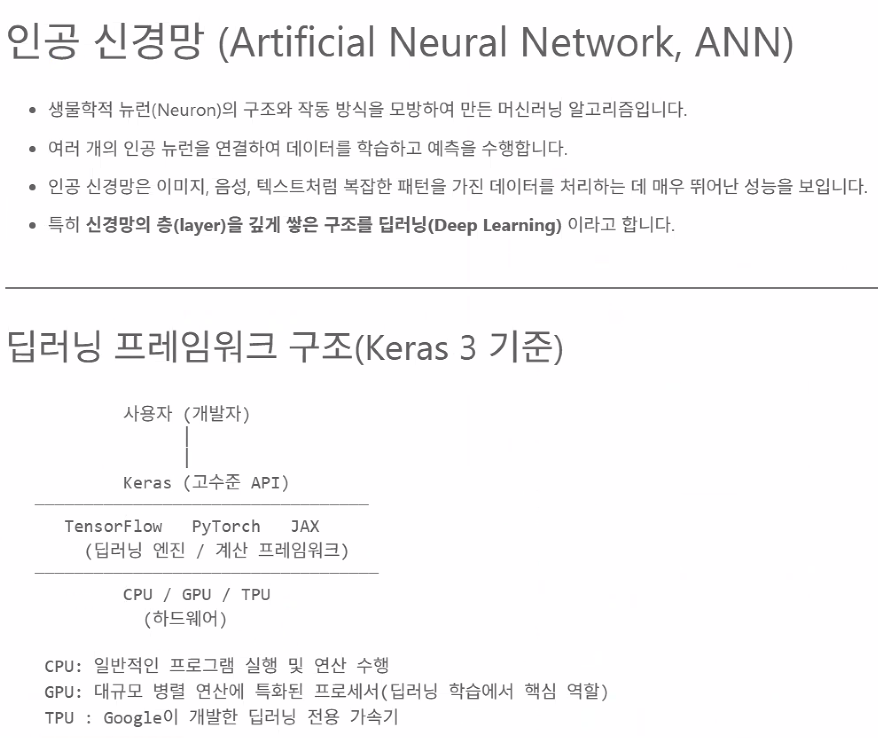

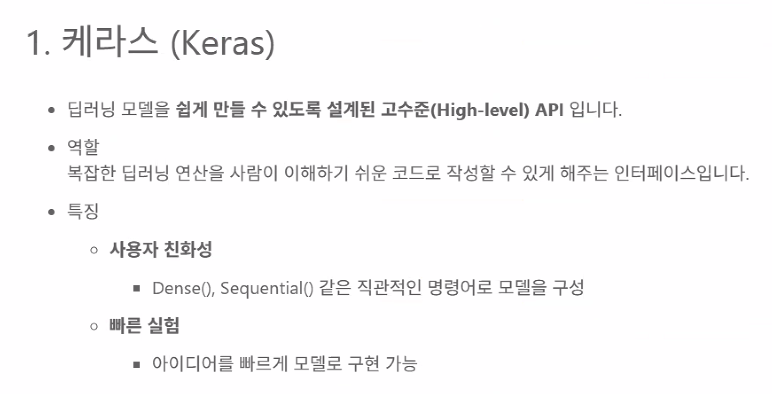

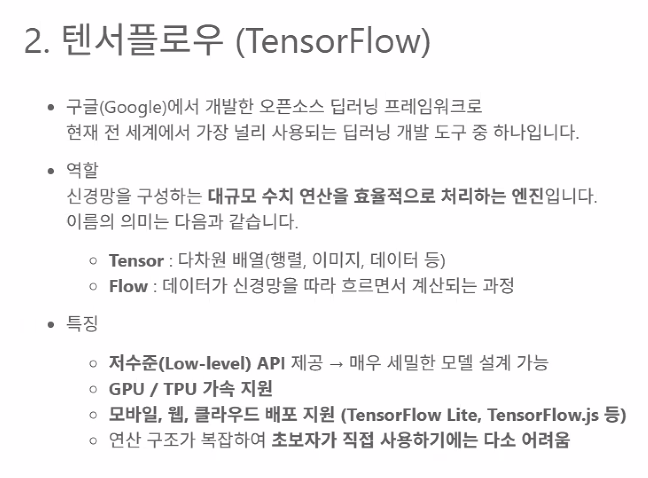

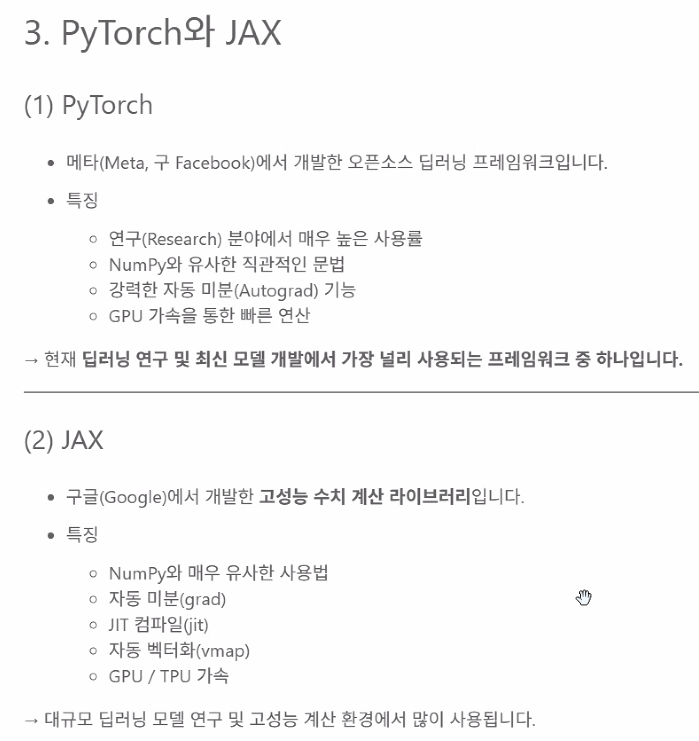

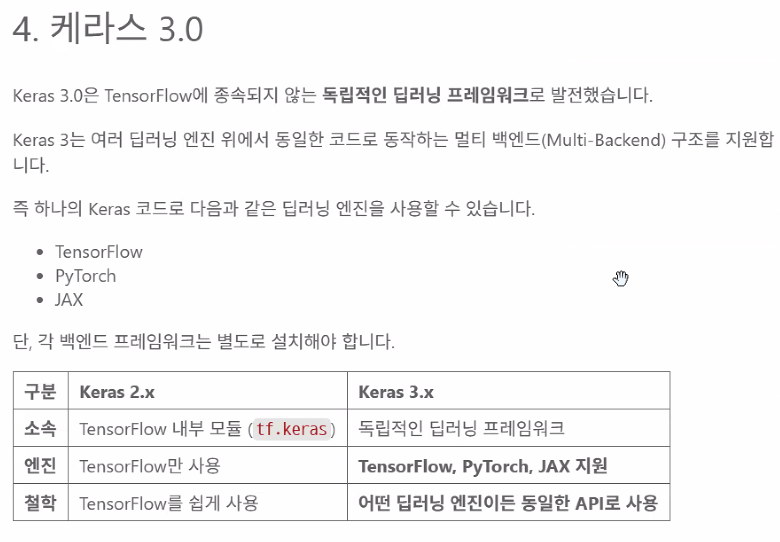

In [ ]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


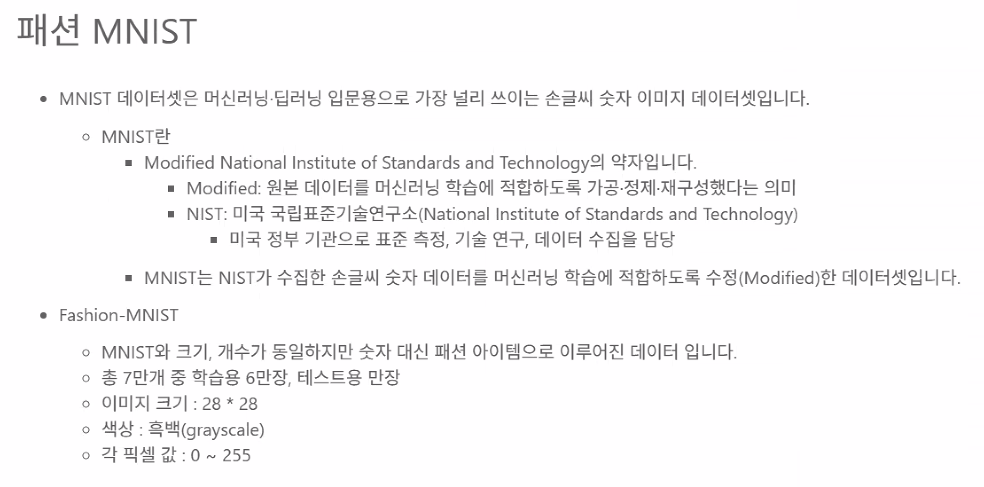

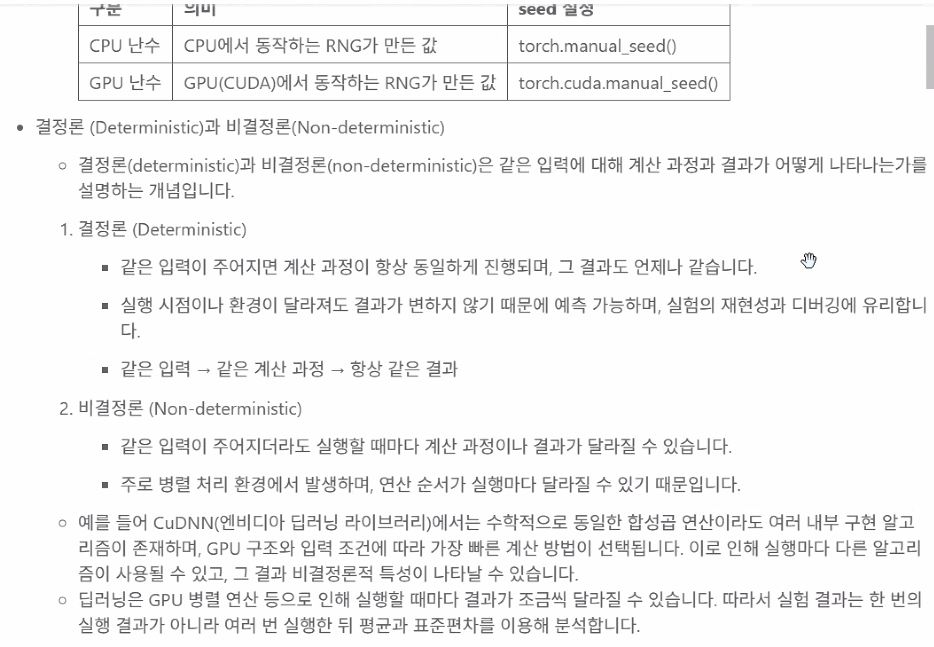

In [ ]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

tf.config.experimental.enable_op_determinism()

In [ ]:
import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [ ]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


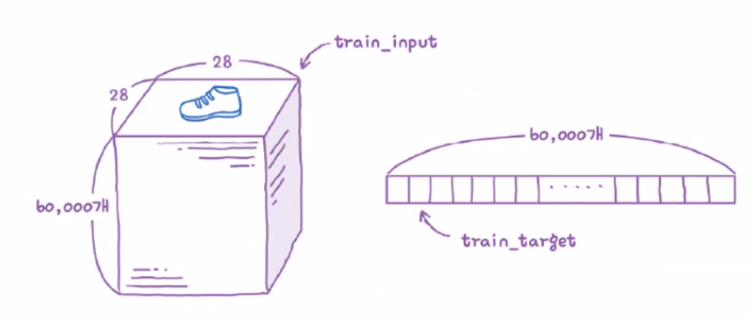

In [ ]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


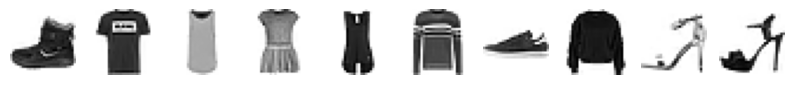

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()

In [ ]:
print(train_target[:10])

[9 0 0 3 0 2 7 2 5 5]


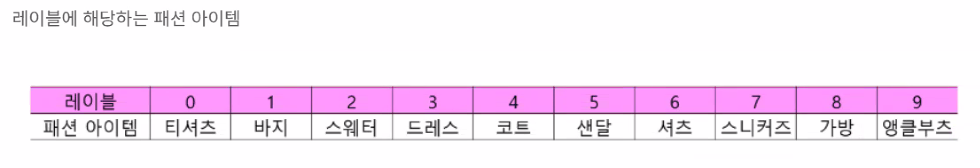

In [ ]:
import numpy as np

print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


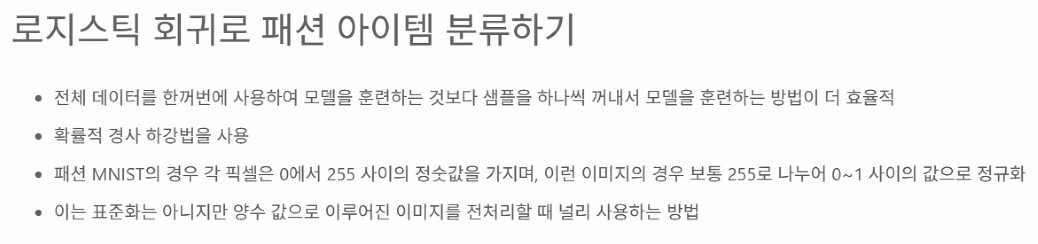

In [ ]:
train_scaled = train_input / 255.0

train_scaled = train_scaled.reshape(-1, 28*28)

In [ ]:
print(train_scaled.shape)

(60000, 784)


In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)

scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(scores)

print(np.mean(scores['test_score']))

{'fit_time': array([2.70294309, 2.70695329, 2.73717499, 2.73216796, 2.99516273]), 'score_time': array([0.01954341, 0.01754141, 0.02876043, 0.02670622, 0.01242995]), 'test_score': array([0.83      , 0.81991667, 0.82008333, 0.80766667, 0.81958333])}
0.81945


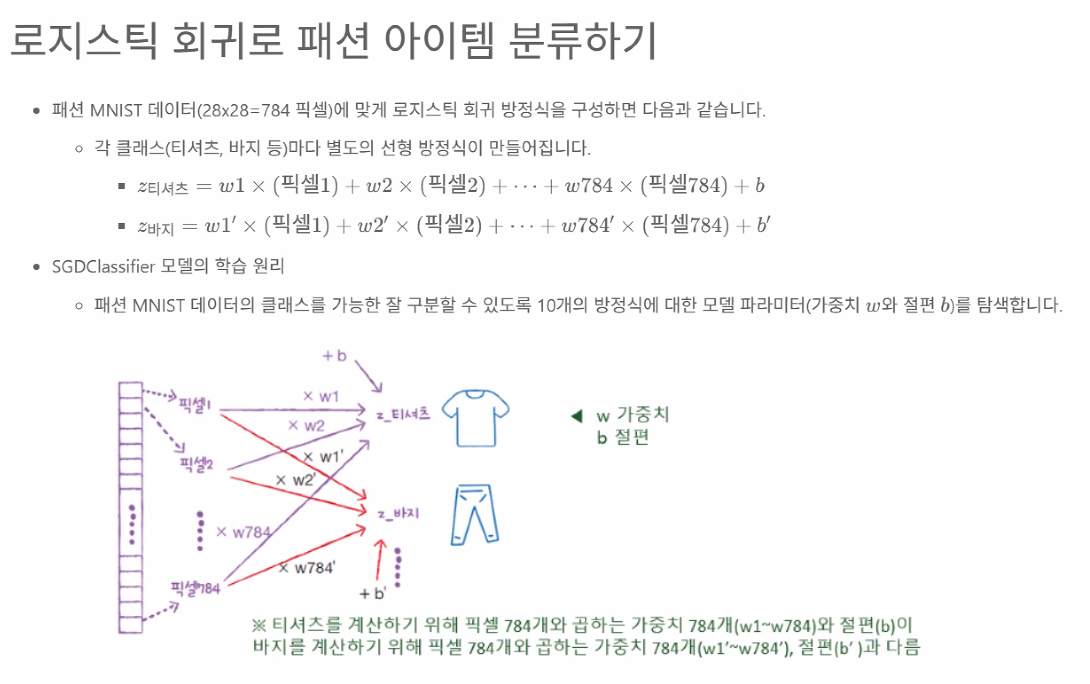

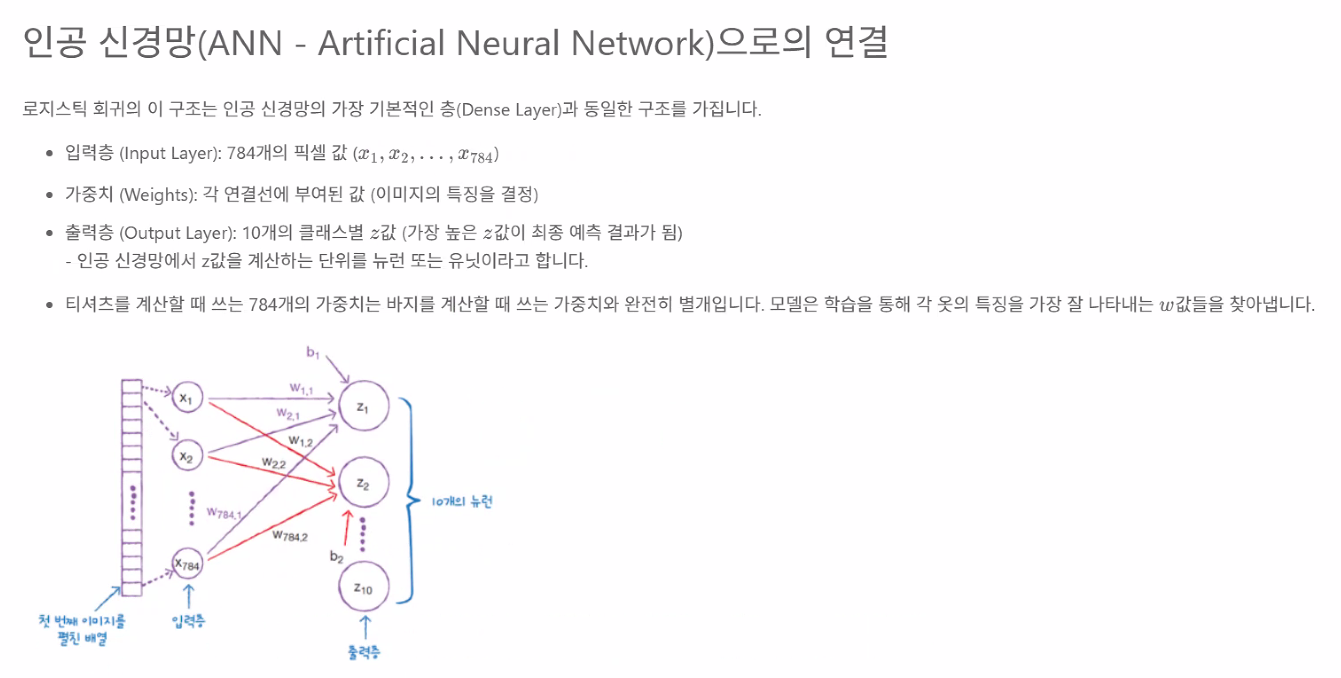

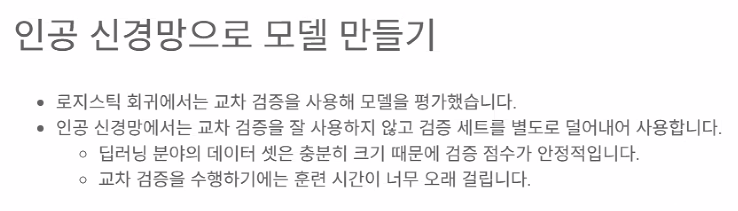

In [ ]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [ ]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [ ]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


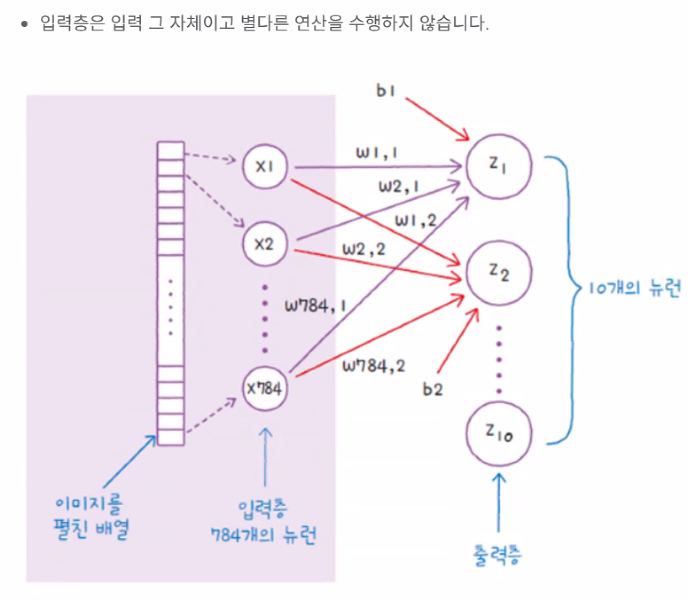

In [ ]:
inputs = keras.layers.Input(shape=(784,))

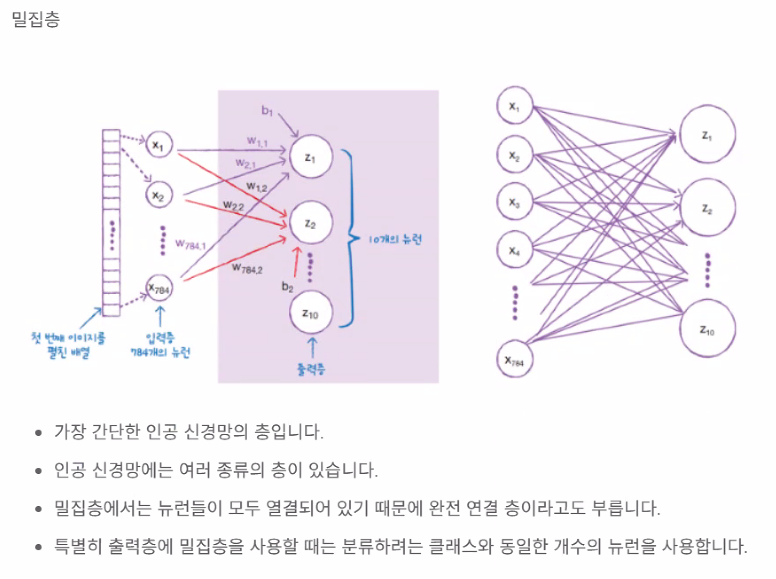

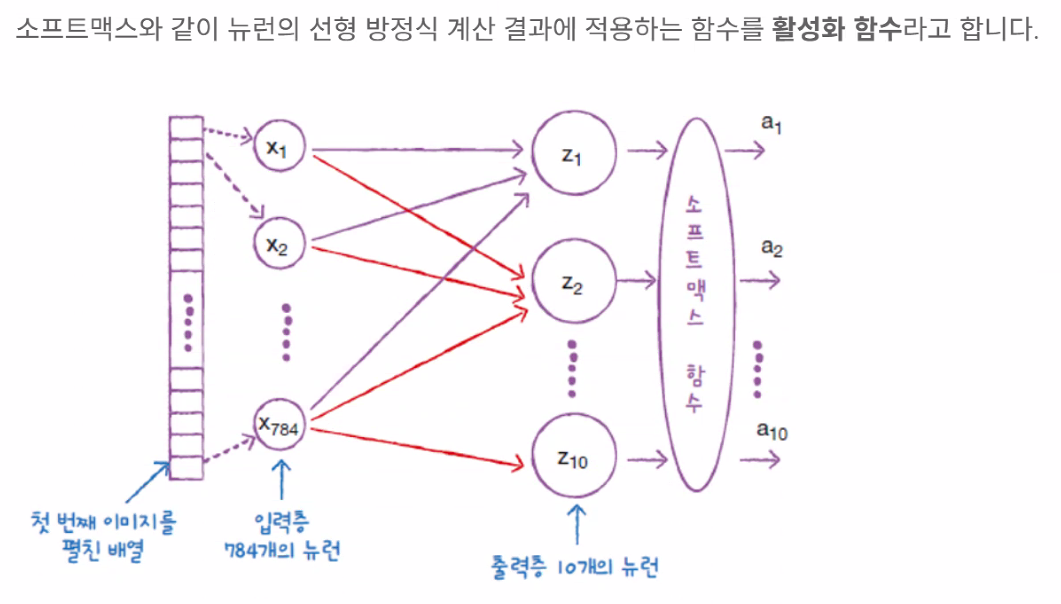

In [ ]:
dense = keras.layers.Dense(10, activation='softmax')

In [ ]:
model = keras.Sequential([inputs, dense])

In [ ]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step - accuracy: 0.7947 - loss: 0.6069
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.8388 - loss: 0.4742
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.8470 - loss: 0.4501
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.8512 - loss: 0.4374
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.8544 - loss: 0.4291


In [ ]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - accuracy: 0.8458 - loss: 0.4444


[0.4444445073604584, 0.8458333611488342]

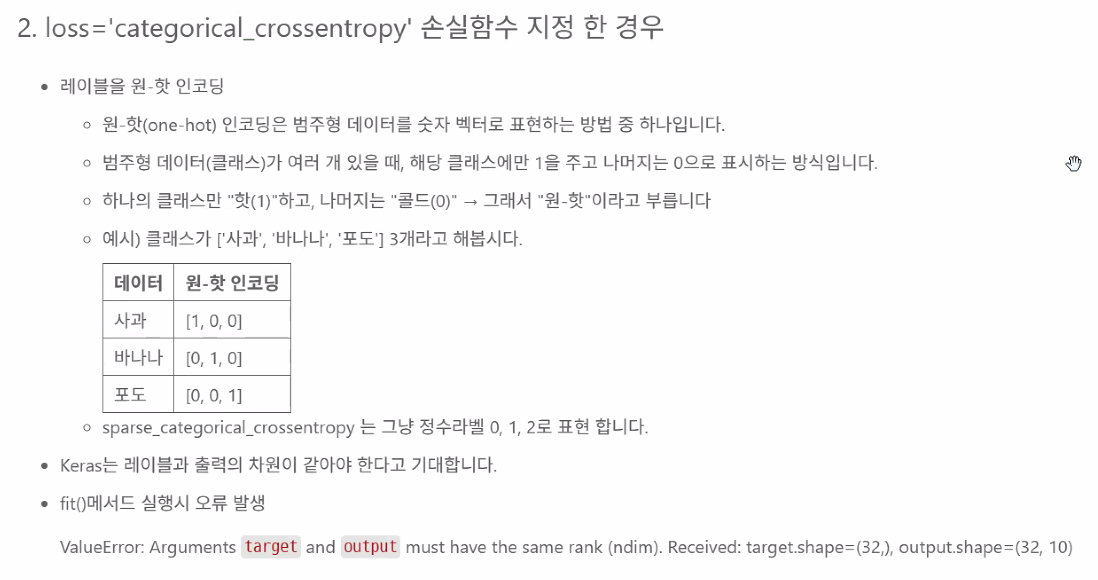

In [ ]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [ ]:
train_target2 = keras.utils.to_categorical(train_target)
print(train_target2)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [ ]:
val_target2 = keras.utils.to_categorical(val_target)
print(val_target2)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [ ]:
inputs = keras.layers.Input(shape=(784,))

dense = keras.layers.Dense(10, activation='softmax')

model2 = keras.Sequential([inputs, dense])

model2.compile(loss='categorical_crossentropy', metrics=['accuracy'])

model2.fit(train_scaled, train_target2, epochs=5)

model2.evaluate(val_scaled, val_target2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.7925 - loss: 0.6082
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step - accuracy: 0.8378 - loss: 0.4744
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - accuracy: 0.8467 - loss: 0.4501
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 555us/step - accuracy: 0.8513 - loss: 0.4372
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - accuracy: 0.8536 - loss: 0.4290
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8465 - loss: 0.4437


[0.4437466263771057, 0.8464999794960022]